In [ ]:
import time
import os
import threadpoolctl

os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["BLIS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
threadpoolctl.threadpool_limits(1, "blas")
threadpoolctl.threadpool_limits(1, "openmp")

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, make_classification
from sklearn.metrics import mean_absolute_error, roc_auc_score, adjusted_rand_score
from sklearn.model_selection import train_test_split


## Линейная регрессия

In [3]:
def LinReg_comprasion(X_train, X_test, y_train, y_test, N_iter, verbose):
    
    from sklearn_upgrade.linear_model import LinearRegression as NewLinearRegression
    from sklearn.linear_model import LinearRegression

    NewLinReg = NewLinearRegression(n_jobs=1)
    OldLinReg = LinearRegression(n_jobs=1)

    if verbose: print(f"[INFO] X_train size: {X_train.shape[0]}\n")
    
    time_arr_new = []
    time_arr_old = []
    MAE_new = []
    MAE_old = []
    for i in range(N_iter):
        
        start_time_1 = time.perf_counter()  
        NewLinReg.fit(X_train, y_train)
        end_time_1 = time.perf_counter()
        
        execution_time_1 = end_time_1 - start_time_1
        time_arr_new.append(execution_time_1)
        
        metr_1 = mean_absolute_error(y_test, NewLinReg.predict(X_test))
        MAE_new.append(metr_1)
        if verbose: print(f"NewLinReg, итерация - {i+1}: Время - {execution_time_1:.6f} сек.  MAE - {metr_1:.4f}")
        
        start_time_2 = time.perf_counter()  
        OldLinReg.fit(X_train, y_train)
        end_time_2 = time.perf_counter()
        
        execution_time_2 = end_time_2 - start_time_2
        time_arr_old.append(execution_time_2)
        
        metr_2 = mean_absolute_error(y_test, OldLinReg.predict(X_test))
        MAE_old.append(metr_2)
        if verbose: print(f"OldLinReg, итерация - {i+1}: Время - {execution_time_2:.6f} сек.  MAE - {metr_2:.4f}")

    t_old = np.mean(time_arr_old)
    t_new = np.mean(time_arr_new)
    M_old = np.mean(MAE_old)
    M_new = np.mean(MAE_new)
    if verbose:
        print(f"\n- Итоговые результаты старой OldLinReg: \n Время - {t_old:.6f} сек.  MAE - {M_old:.4f}")
        print(f"\n- Итоговые результаты новой NewLinReg: \n Время - {t_new:.6f} сек.  MAE - {M_new:.4f}\n")
    
    return t_old, M_old, t_new, M_new

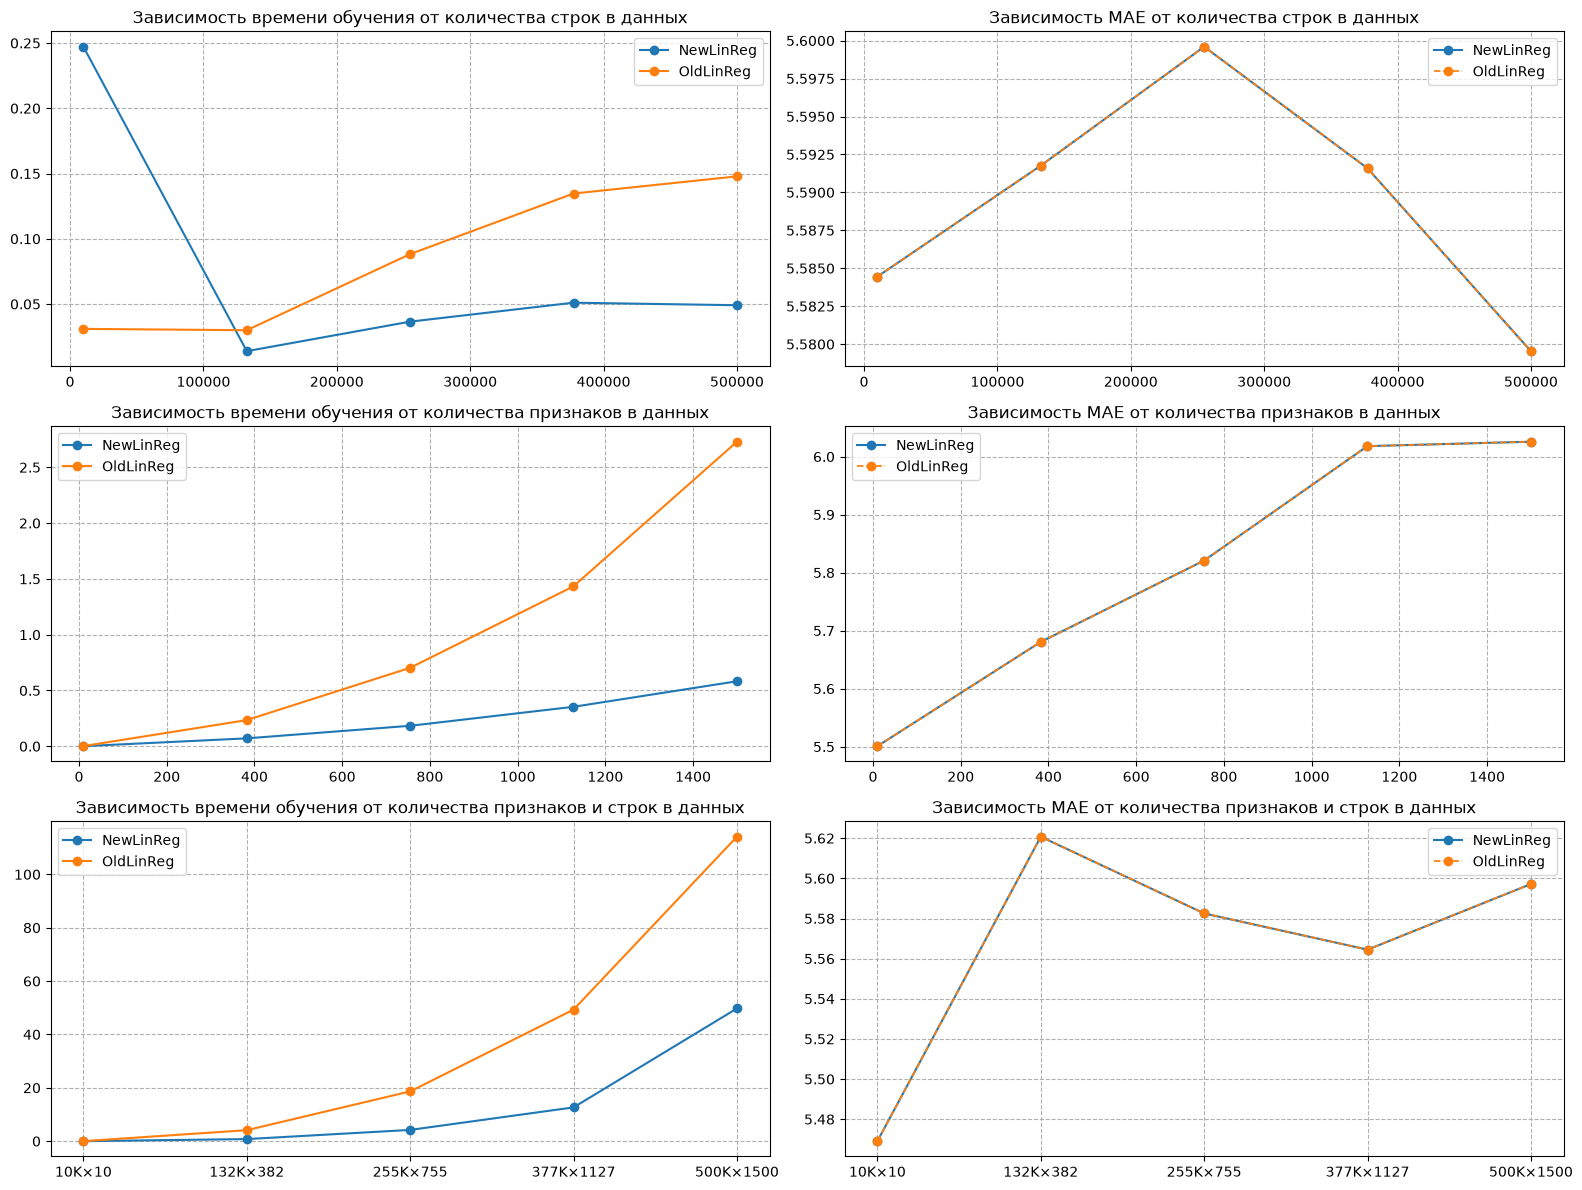

In [ ]:
N_iter = 3
matr_len = np.linspace(10_000, 500_000, 5).astype(int)
feat = np.linspace(10, 1_500, 5).astype(int)

time_arr_plot_New_1 = []
time_arr_plot_Old_1 = []
MAE_arr_plot_New_1 = []
MAE_arr_plot_Old_1 = []

fig, axs = plt.subplots(3, 2, figsize=(16, 12))

for l in matr_len:
    X, y = make_regression(n_samples=l, n_features=feat[0], noise=7, random_state=40)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    t_o, M_o, t_n, M_n = LinReg_comprasion(X_train, X_test, y_train, y_test, N_iter, False)
    time_arr_plot_New_1.append(t_n)
    time_arr_plot_Old_1.append(t_o)
    MAE_arr_plot_New_1.append(M_n)
    MAE_arr_plot_Old_1.append(M_o)
    
    
axs[0][0].plot(matr_len, time_arr_plot_New_1, marker='o', linestyle='-', label='NewLinReg')
axs[0][0].plot(matr_len, time_arr_plot_Old_1, marker='o', linestyle='-', label='OldLinReg')
axs[0][0].legend()
axs[0][0].set_ylabel('Время обучения, с')
axs[0][0].set_title('Зависимость времени обучения от количества строк в данных')
axs[0][0].grid(ls='--')

axs[0][1].plot(matr_len, MAE_arr_plot_New_1, marker='o', linestyle='-', label='NewLinReg')
axs[0][1].plot(matr_len, MAE_arr_plot_Old_1, marker='o', linestyle='--', label='OldLinReg', linewidth=1.25)
axs[0][1].legend()
axs[0][1].set_title('Зависимость MAE от количества строк в данных')
axs[0][1].grid(ls='--')

time_arr_plot_New_1 = []
time_arr_plot_Old_1 = []
MAE_arr_plot_New_1 = []
MAE_arr_plot_Old_1 = []

for f in feat:
    X, y = make_regression(n_samples=matr_len[0], n_features=f, noise=7, random_state=40)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    t_o, M_o, t_n, M_n = LinReg_comprasion(X_train, X_test, y_train, y_test, N_iter, False)
    time_arr_plot_New_1.append(t_n)
    time_arr_plot_Old_1.append(t_o)
    MAE_arr_plot_New_1.append(M_n)
    MAE_arr_plot_Old_1.append(M_o)
    
    
axs[1][0].plot(feat, time_arr_plot_New_1, marker='o', linestyle='-', label='NewLinReg')
axs[1][0].plot(feat, time_arr_plot_Old_1, marker='o', linestyle='-', label='OldLinReg')
axs[1][0].legend()
axs[1][0].set_ylabel('Время обучения, с')
axs[1][0].set_title('Зависимость времени обучения от количества признаков в данных')
axs[1][0].grid(ls='--')

axs[1][1].plot(feat, MAE_arr_plot_New_1, marker='o', linestyle='-', label='NewLinReg')
axs[1][1].plot(feat, MAE_arr_plot_Old_1, marker='o', linestyle='--', label='OldLinReg', linewidth=1.25)
axs[1][1].legend()
axs[1][1].set_title('Зависимость MAE от количества признаков в данных')
axs[1][1].grid(ls='--')


time_arr_plot_New_1 = []
time_arr_plot_Old_1 = []
MAE_arr_plot_New_1 = []
MAE_arr_plot_Old_1 = []

range_indxs = range(len(matr_len))
for idx in range_indxs:
    X, y = make_regression(n_samples=matr_len[idx], n_features=feat[idx], noise=7, random_state=40)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    t_o, M_o, t_n, M_n = LinReg_comprasion(X_train, X_test, y_train, y_test, N_iter, False)
    time_arr_plot_New_1.append(t_n)
    time_arr_plot_Old_1.append(t_o)
    MAE_arr_plot_New_1.append(M_n)
    MAE_arr_plot_Old_1.append(M_o)
    
    
labels = [f"{n//1000}K×{m}" for n, m in zip(matr_len, feat)]
axs[2][0].plot(range_indxs, time_arr_plot_New_1, marker='o', linestyle='-', label='NewLinReg')
axs[2][0].plot(range_indxs, time_arr_plot_Old_1, marker='o', linestyle='-', label='OldLinReg')
axs[2][0].set_xticks(range_indxs, labels)
axs[2][0].legend()
axs[2][0].set_title('Зависимость времени обучения от количества признаков и строк в данных')
axs[2][0].grid(ls='--')

axs[2][1].plot(range_indxs, MAE_arr_plot_New_1, marker='o', linestyle='-', label='NewLinReg')
axs[2][1].plot(range_indxs, MAE_arr_plot_Old_1, marker='o', linestyle='--', label='OldLinReg', linewidth=1.25)
axs[2][1].set_xticks(range_indxs, labels)
axs[2][1].legend()
axs[2][1].set_title('Зависимость MAE от количества признаков и строк в данных')
axs[2][1].grid(ls='--')

plt.tight_layout()
plt.show()

## SVM

In [5]:
def SVM_comprasion(X_train, X_test, y_train, y_test, N_iter, verbose):
    from sklearn_upgrade.svm import SVC as NewSVC
    from sklearn.svm import SVC

    cache_size = 5000
    NewSVM = NewSVC(C=1, gamma='scale', kernel='rbf', cache_size=cache_size, random_state=42)
    OldSVM = SVC(C=1, gamma='scale', kernel='rbf', cache_size=cache_size, random_state=42)

    time_arr_new = []
    time_arr_old = []
    auc_new = []
    auc_old = []

    for i in range(N_iter):
        start = time.perf_counter()
        NewSVM.fit(X_train, y_train)
        time_arr_new.append(time.perf_counter() - start)
        auc_new.append(roc_auc_score(y_test, NewSVM.decision_function(X_test)))

        start = time.perf_counter()
        OldSVM.fit(X_train, y_train)
        time_arr_old.append(time.perf_counter() - start)
        auc_old.append(roc_auc_score(y_test, OldSVM.decision_function(X_test)))

    t_old = np.mean(time_arr_old)
    t_new = np.mean(time_arr_new)
    a_old = np.mean(auc_old)
    a_new = np.mean(auc_new)

    if verbose:
        print(f"OldSVM: time={t_old:.6f}  AUC={a_old:.4f}")
        print(f"NewSVM: time={t_new:.6f}  AUC={a_new:.4f}")

    return t_old, a_old, t_new, a_new

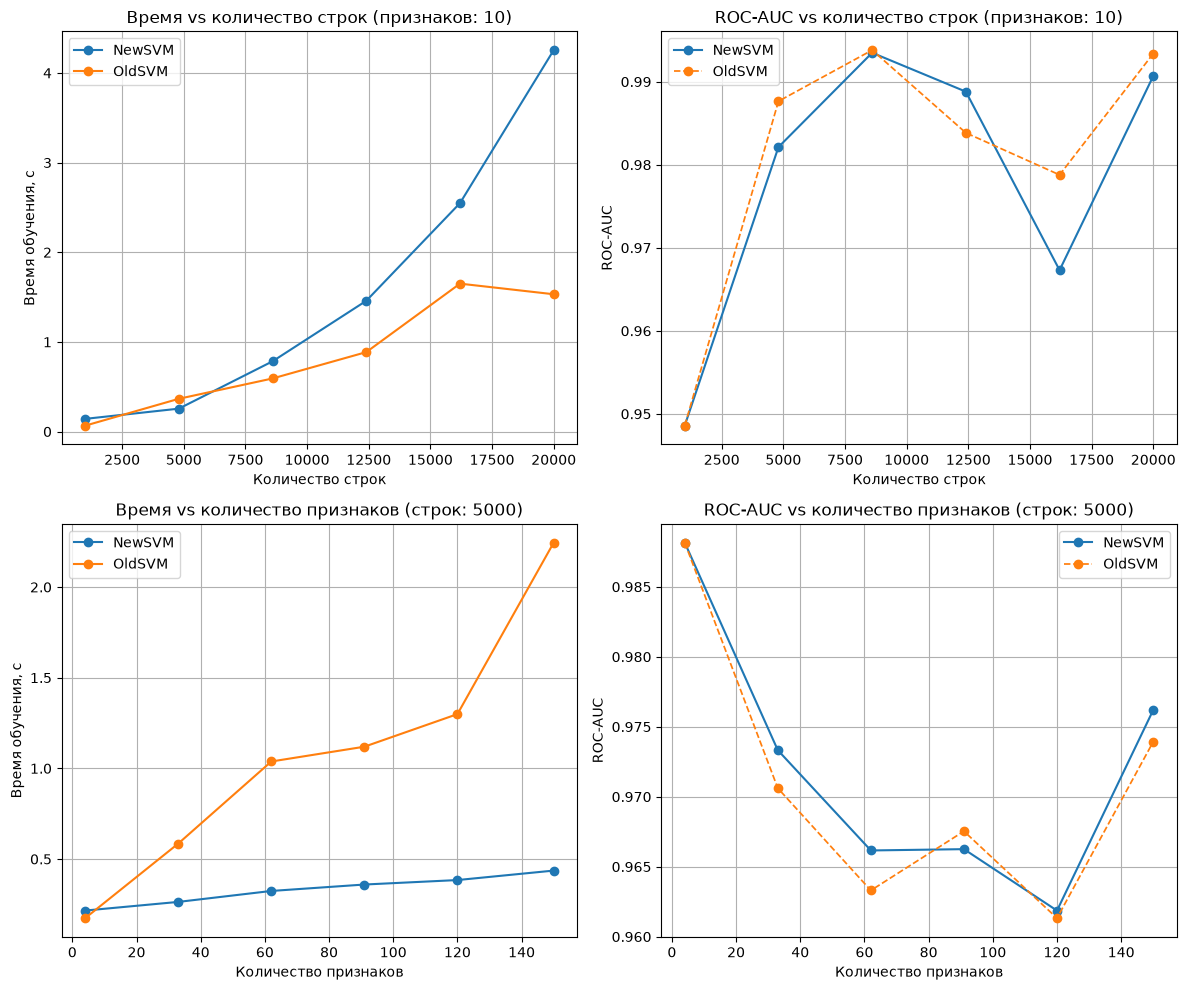

In [6]:

N_iter = 4
n_samples_list = np.linspace(1000, 20000, 6).astype(int)
n_features_list = np.linspace(4, 150, 6).astype(int)
fixed_n_features = 10
fixed_n_samples = 5000

time_new_n, time_old_n, auc_new_n, auc_old_n = [], [], [], []
for n in n_samples_list:
    X, y = make_classification(n_samples=n, n_features=fixed_n_features, n_classes=2, 
                               random_state=42, n_clusters_per_class=1, n_informative=2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    t_o, a_o, t_n, a_n = SVM_comprasion(X_train, X_test, y_train, y_test, N_iter, False)
    time_new_n.append(t_n)
    time_old_n.append(t_o)
    auc_new_n.append(a_n)
    auc_old_n.append(a_o)
    
time_new_m, time_old_m, auc_new_m, auc_old_m = [], [], [], []
for m in n_features_list:
    X, y = make_classification(n_samples=fixed_n_samples, n_features=m, n_classes=2, 
                               random_state=42, n_clusters_per_class=1, n_informative=2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    t_o, a_o, t_n, a_n = SVM_comprasion(X_train, X_test, y_train, y_test, N_iter, False)
    time_new_m.append(t_n)
    time_old_m.append(t_o)
    auc_new_m.append(a_n)
    auc_old_m.append(a_o)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0,0].plot(n_samples_list, time_new_n, marker='o', label='NewSVM')
axs[0,0].plot(n_samples_list, time_old_n, marker='o', label='OldSVM')
axs[0,0].set_xlabel('Количество строк')
axs[0,0].set_ylabel('Время обучения, с')
axs[0,0].set_title(f'Время vs количество строк (признаков: {fixed_n_features})')
axs[0,0].legend()
axs[0,0].grid(True)

axs[0,1].plot(n_samples_list, auc_new_n, marker='o', label='NewSVM')
axs[0,1].plot(n_samples_list, auc_old_n, marker='o', label='OldSVM', linestyle='--', linewidth=1.25)
axs[0,1].set_xlabel('Количество строк')
axs[0,1].set_ylabel('ROC-AUC')
axs[0,1].set_title(f'ROC-AUC vs количество строк (признаков: {fixed_n_features})')
axs[0,1].legend()
axs[0,1].grid(True)

axs[1,0].plot(n_features_list, time_new_m, marker='o', label='NewSVM')
axs[1,0].plot(n_features_list, time_old_m, marker='o', label='OldSVM')
axs[1,0].set_xlabel('Количество признаков')
axs[1,0].set_ylabel('Время обучения, с')
axs[1,0].set_title(f'Время vs количество признаков (строк: {fixed_n_samples})')
axs[1,0].legend()
axs[1,0].grid(True)

axs[1,1].plot(n_features_list, auc_new_m, marker='o', label='NewSVM')
axs[1,1].plot(n_features_list, auc_old_m, marker='o', linestyle='--', linewidth=1.25, label='OldSVM')
axs[1,1].set_xlabel('Количество признаков')
axs[1,1].set_ylabel('ROC-AUC')
axs[1,1].set_title(f'ROC-AUC vs количество признаков (строк: {fixed_n_samples})')
axs[1,1].legend()
axs[1,1].grid(True)

plt.tight_layout()
plt.show()

## KMeans

In [7]:
def Kmeans_comprasion(X_train, X_test, y_train, y_test, N_iter, verbose, rs):
    from sklearn_upgrade.cluster import KMeans as NewKMeans
    from sklearn.cluster import KMeans

    NewKM = NewKMeans(random_state=rs)
    OldKM = KMeans(random_state=rs)

    time_new, time_old, ari_new, ari_old = [], [], [], []

    for _ in range(N_iter):
        t0 = time.perf_counter()
        NewKM.fit(X_train)
        time_new.append(time.perf_counter() - t0)
        ari_new.append(adjusted_rand_score(y_test, NewKM.predict(X_test)))

        t0 = time.perf_counter()
        OldKM.fit(X_train)
        time_old.append(time.perf_counter() - t0)
        ari_old.append(adjusted_rand_score(y_test, OldKM.predict(X_test)))
    
    t_old = np.mean(time_old)
    t_new = np.mean(time_new)
    a_old = np.mean(ari_old)
    a_new = np.mean(ari_new)
    
    if verbose:
        print(f"OldSVM: time={t_old:.6f}  AUC={a_old:.4f}")
        print(f"NewSVM: time={t_new:.6f}  AUC={a_new:.4f}")

    return t_old, a_old, t_new, a_new

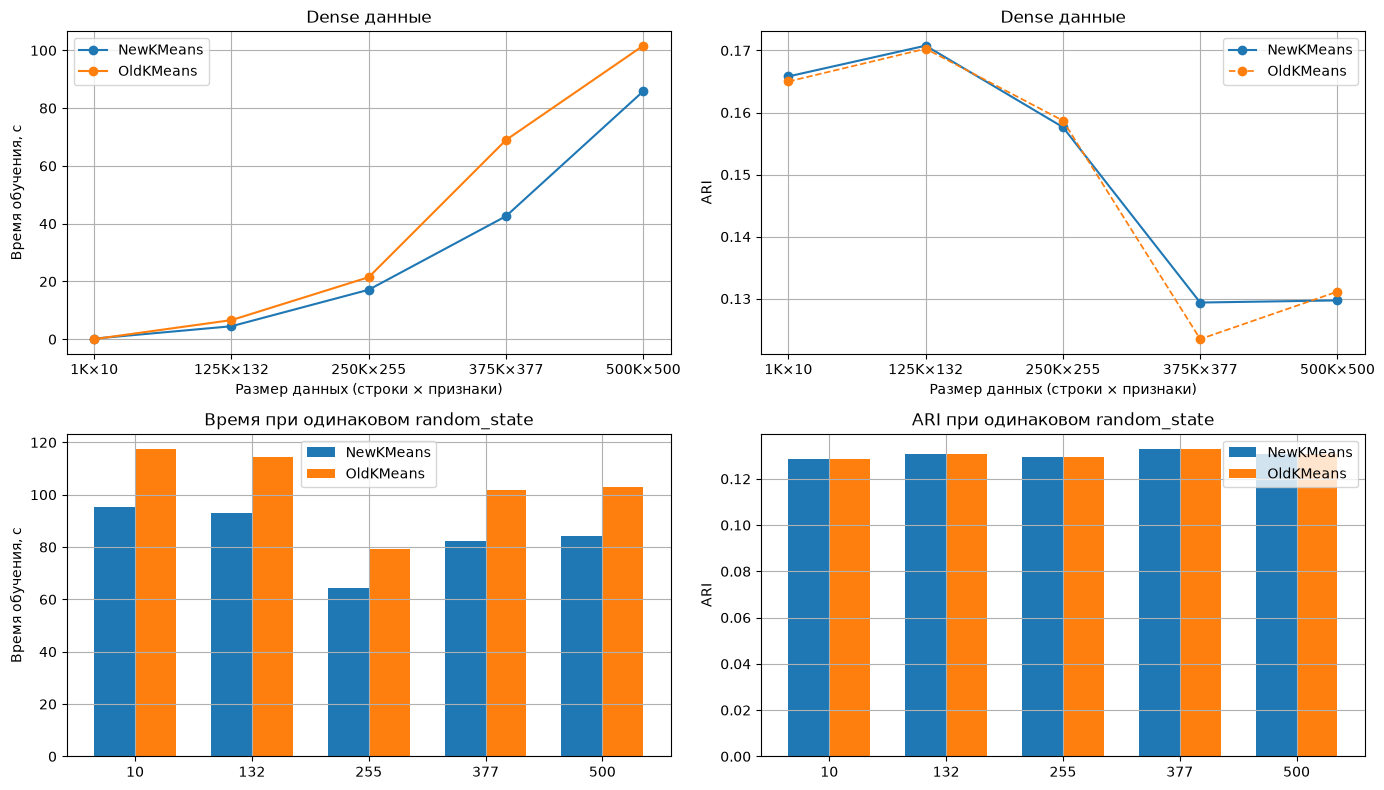

In [ ]:
N_iter = 2
n_samples_arr = np.linspace(1_000, 500_000, 5).astype(int)
n_features_arr = np.linspace(10, 500, 5).astype(int)
n_fix = 500_000
m_fix = 200

t_old_rs, t_new_rs, ari_old_rs, ari_new_rs = [], [], [], []
t_old_ds, t_new_ds, ari_old_ds, ari_new_ds = [], [], [], []

for n, m in zip(n_samples_arr, n_features_arr):
    X, y = make_classification(n_samples=n, n_features=m, n_classes=2, 
                               random_state=42, n_clusters_per_class=1, n_informative=2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    to, ao, tn, an = Kmeans_comprasion(X_train, X_test, y_train, y_test, N_iter, False, None)
    t_old_ds.append(to)
    ari_old_ds.append(ao)
    t_new_ds.append(tn)
    ari_new_ds.append(an)

rs_list = np.linspace(10, 500, 5).astype(int)
for rs in rs_list:
    X, y = make_classification(n_samples=n, n_features=m, n_classes=2, 
                               random_state=42, n_clusters_per_class=1, n_informative=2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    to, ao, tn, an = Kmeans_comprasion(X_train, X_test, y_train, y_test, N_iter, False, rs)
    t_old_rs.append(to)
    ari_old_rs.append(ao)
    t_new_rs.append(tn)
    ari_new_rs.append(an)

labels = [f"{n//1000}K×{m}" if n>=1000 else f"{n}×{m}" for n, m in zip(n_samples_arr, n_features_arr)]
x = np.arange(len(labels))

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

axs[0,0].plot(x, t_new_ds, marker='o', label='NewKMeans')
axs[0,0].plot(x, t_old_ds, marker='o', label='OldKMeans')
axs[0,0].set_xticks(x, labels)
axs[0,0].set_xlabel('Размер данных (строки × признаки)')
axs[0,0].set_ylabel('Время обучения, с')
axs[0,0].set_title('Dense данные')
axs[0,0].legend()
axs[0,0].grid(True)

axs[0,1].plot(x, ari_new_ds, marker='o', label='NewKMeans')
axs[0,1].plot(x, ari_old_ds, marker='o', label='OldKMeans', linestyle='--', linewidth=1.25)
axs[0,1].set_xticks(x, labels)
axs[0,1].set_xlabel('Размер данных (строки × признаки)')
axs[0,1].set_ylabel('ARI')
axs[0,1].set_title('Dense данные')
axs[0,1].legend()
axs[0,1].grid(True)

x = np.arange(len(rs_list))
width = 0.35

axs[1,0].bar(x - width/2, t_new_rs, width, label='NewKMeans')
axs[1,0].bar(x + width/2, t_old_rs, width, label='OldKMeans')
axs[1,0].set_ylabel('Время обучения, с')
axs[1,0].set_title('Время при одинаковом random_state')
axs[1,0].set_xticks(x)
axs[1,0].set_xticklabels(rs_list)
axs[1,0].legend()
axs[1,0].grid(True)

axs[1,1].bar(x - width/2, ari_new_rs, width, label='NewKMeans')
axs[1,1].bar(x + width/2, ari_old_rs, width, label='OldKMeans')
axs[1,1].set_ylabel('ARI')
axs[1,1].set_title('ARI при одинаковом random_state')
axs[1,1].set_xticks(x)
axs[1,1].set_xticklabels(rs_list)
axs[1,1].legend()
axs[1,1].grid(True)

plt.tight_layout()
plt.show()